<a href="https://colab.research.google.com/github/Anthea05/Anthea_machine-learning/blob/main/JS05/Tugas1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('voice.csv')

In [ ]:
X = df.drop(columns=['label'])
y = df['label']

y = LabelEncoder().fit_transform(y)
selector = SelectKBest(score_func=f_classif, k=10)
X = selector.fit_transform(X, y)

print("Fitur terbaik:", df.drop(columns=['label']).columns[selector.get_support()].tolist())

Fitur terbaik: ['meanfreq', 'sd', 'median', 'Q25', 'IQR', 'sp.ent', 'sfm', 'centroid', 'meanfun', 'maxdom']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

train_acc = []
test_acc = []
k_range = range(1, 31)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, knn.predict(X_train)))
    test_acc.append(accuracy_score(y_test, knn.predict(X_test)))

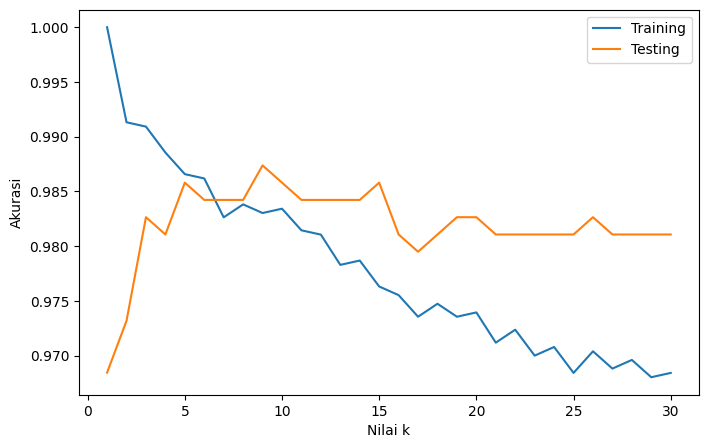

Nilai k terbaik: 9
Akurasi tertinggi: 0.9873817034700315


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, train_acc, label='Training')
plt.plot(k_range, test_acc, label='Testing')
plt.xlabel('Nilai k')
plt.ylabel('Akurasi')
plt.legend()
plt.show()

best_k = k_range[np.argmax(test_acc)]
print("Nilai k terbaik:", best_k)
print("Akurasi tertinggi:", max(test_acc))

2. fitur yang saya gunakan untuk mendapat hasil terbaik adalah
- meanfun (rata-rata frekuensi fundamental)
- IQR (Interquantile Range)
- Q25 (Kuartil pertama frekuensi)
- sp.ent (Spectral Entropy)
- sd (Standar deviasi frekuensi)
- sfm (Spectral Flatness Measure)
- meanfreq (Rata-rata frekuensi)
- centroid (Frequency Centroid)
3. Nilai k terbaik: 9
Akurasi Testing Maksimal: 0.9874 (98.74%)
alasannya adalah nilai k = 9 dipilih sebagai pilihan terbaik karena pada titik tersebut garis "Testing" (oranye) mencapai titik tertinggi. Kita menghindari nilai k yang terlalu kecil (seperti k=1), karena meskipun garis "Training" (biru) menunjukkan akurasi sempurna 1.0 (100%), akurasi testingnya justru sangat rendah, yang jelas mengindikasikan terjadinya overfitting (model hanya menghafal data pelatihan). Nilai k = 9 menawarkan keseimbangan optimal antara generalisasi model dan kompleksitas batasan keputusan. Selain itu, 9 adalah bilangan ganjil yang merupakan praktik terbaik dalam kNN untuk menghindari kemungkinan terjadinya hasil voting seri (tie) antara dua kelas.